In [ ]:
!pip install transformers torch pandas scikit-learn

import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
import pandas as pd
from tqdm import tqdm

# Thiết lập device sử dụng GPU T4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


🚀 Đang chạy CHIẾN THUẬT SỐ: 1 trên thiết bị: cuda

--- BƯỚC 2: Đọc và xử lý dữ liệu ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/5


Validation: 100%|██████████| 140/140 [01:01<00:00,  2.27it/s]


...

Train Loss: 1.4327 | Train Acc: 0.9235 | Train F1: 0.8912
Val Loss:   1.4689 | Val Acc:   0.9172 | Val F1:   0.8776
-> Xuất sắc! Val F1 tăng từ 0.8753 lên 0.8776. Đang lưu mô hình...

Epoch 4/5


Validation: 100%|██████████| 140/140 [01:01<00:00,  2.28it/s]


Train Loss: 1.1557 | Train Acc: 0.9373 | Train F1: 0.9122
Val Loss:   1.4918 | Val Acc:   0.9265 | Val F1:   0.8980
-> Xuất sắc! Val F1 tăng từ 0.8776 lên 0.8980. Đang lưu mô hình...

Epoch 5/5


Validation: 100%|██████████| 140/140 [01:01<00:00,  2.28it/s]


Train Loss: 1.0126 | Train Acc: 0.9451 | Train F1: 0.9237
Val Loss:   1.4207 | Val Acc:   0.9270 | Val F1:   0.8932

--- BƯỚC 6: Vẽ biểu đồ và Xuất Confusion Matrix ---


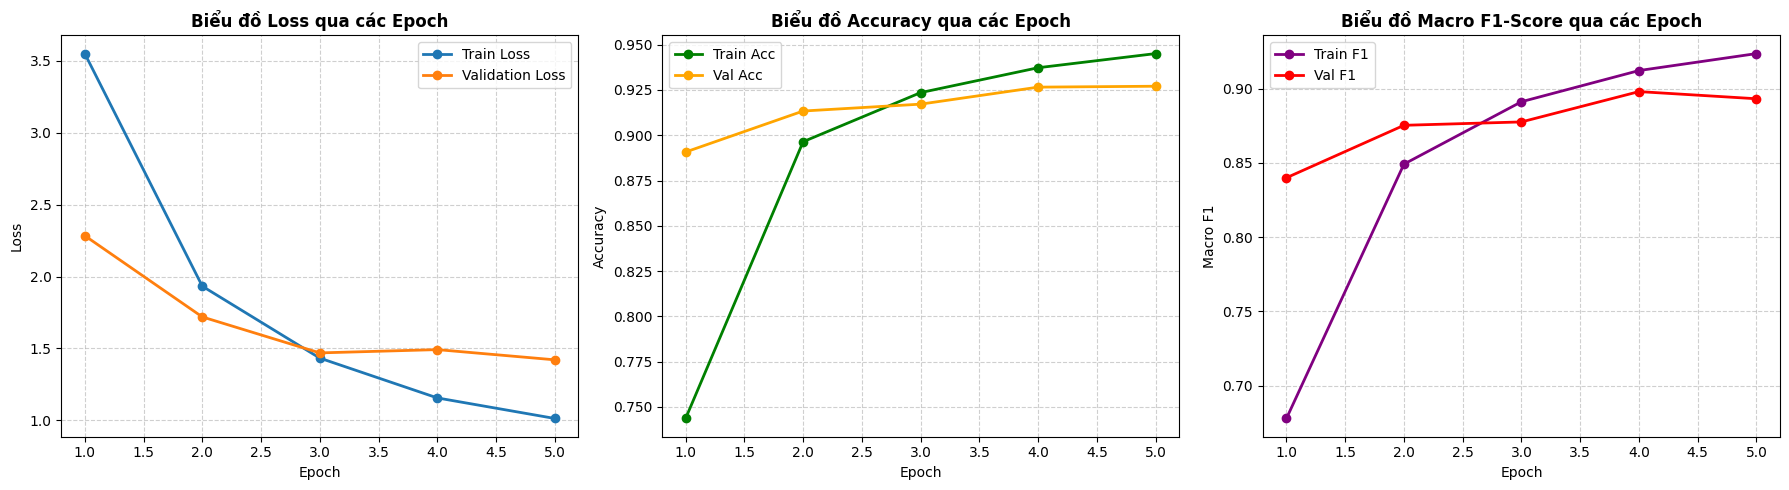

-> Đang tải trọng số tối ưu từ 'best_phobert_absa.pth' để phân tích chi tiết...


Đang đánh giá tập Validation: 100%|██████████| 140/140 [01:01<00:00,  2.27it/s]


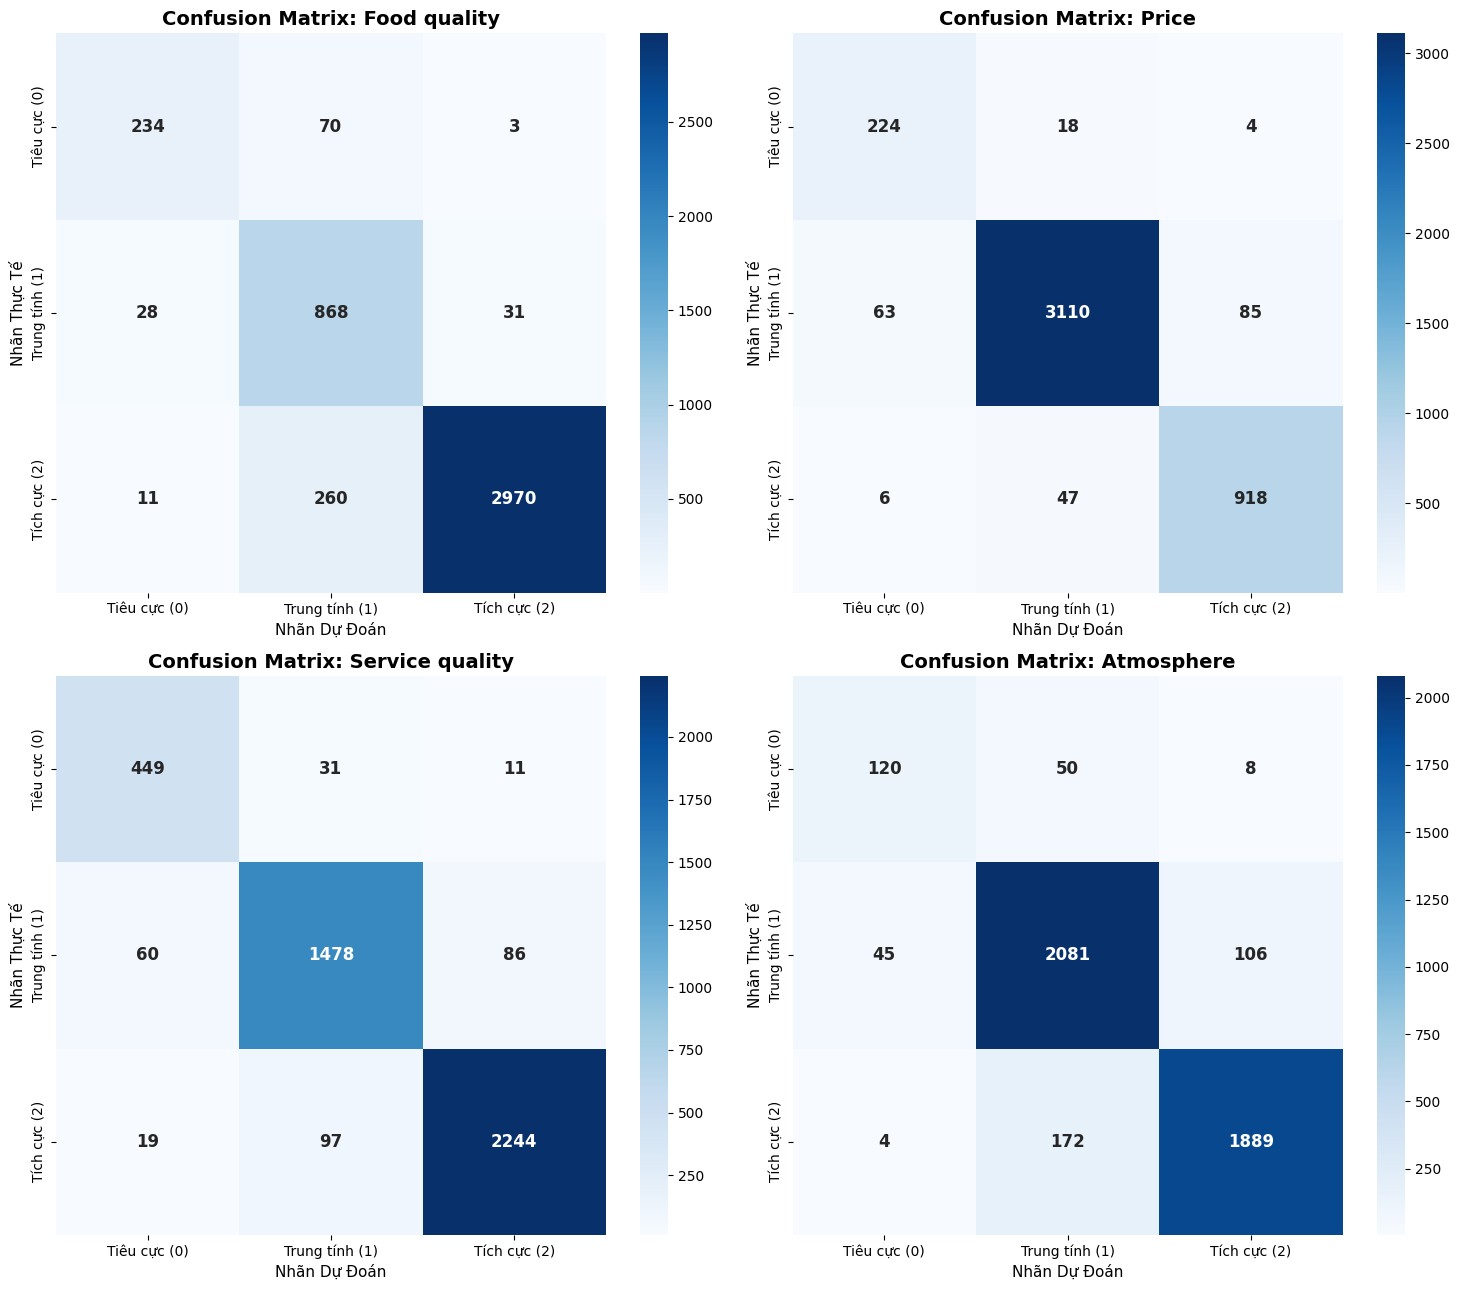


🔥 BẢNG CONFUSION MATRIX ĐỊNH DẠNG MARKDOWN (CHIẾN THUẬT SỐ 1)

### 🎯 Khía cạnh: Food quality
|                        |   Dự đoán Tiêu cực (0) |   Dự đoán Trung tính (1) |   Dự đoán Tích cực (2) |
|:-----------------------|-----------------------:|-------------------------:|-----------------------:|
| Thực tế Tiêu cực (0)   |                    234 |                       70 |                      3 |
| Thực tế Trung tính (1) |                     28 |                      868 |                     31 |
| Thực tế Tích cực (2)   |                     11 |                      260 |                   2970 |

### 🎯 Khía cạnh: Price
|                        |   Dự đoán Tiêu cực (0) |   Dự đoán Trung tính (1) |   Dự đoán Tích cực (2) |
|:-----------------------|-----------------------:|-------------------------:|-----------------------:|
| Thực tế Tiêu cực (0)   |                    224 |                       18 |                      4 |
| Thực tế Trung tính (1) |                     63 

In [5]:
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ==========================================
# CẤU HÌNH CHIẾN THUẬT NÂNG CẤP (QUAN TRỌNG)
# ==========================================
# CHOSEN_STRATEGY = 1 -> Cách 1: Tăng trọng số Loss cho tiêu chí Atmosphere (x2.0)
# CHOSEN_STRATEGY = 2 -> Cách 2: Tinh chỉnh Ngưỡng Quyết Định (Threshold Tuning) lúc Dự đoán
# CHOSEN_STRATEGY = 3 -> Cách 3: Dùng Focal Loss chuyên biệt cho tiêu chí Atmosphere
CHOSEN_STRATEGY = 1

# Các tham số bổ sung cho chiến thuật
ATMOSPHERE_LOSS_SCALE = 2.0  # Dùng cho Cách 1 (Hệ số phạt của Không gian)
NEG_THRESHOLD_ATMOSPHERE = 0.35  # Dùng cho Cách 2 (Chỉ cần nghi ngờ >= 35% là chốt Tiêu cực)
FOCAL_GAMMA = 2.0  # Dùng cho Cách 3

# Cấu hình thiết bị và Epochs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Đang chạy CHIẾN THUẬT SỐ: {CHOSEN_STRATEGY} trên thiết bị: {device}\n")

# ==========================================
# KHỞI TẠO CÁC LỚP HỖ TRỢ (FOCAL LOSS)
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean', label_smoothing=0.1):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs, targets, weight=self.weight,
            reduction='none', label_smoothing=self.label_smoothing
        )
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean': return focal_loss.mean()
        if self.reduction == 'sum': return focal_loss.sum()
        return focal_loss

# ==========================================
# BƯỚC 2: ĐỌC VÀ XỬ LÝ DỮ LIỆU
# ==========================================
print("--- BƯỚC 2: Đọc và xử lý dữ liệu ---")
with open('labeled_results_all_v6.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

def map_label(value):
    if value == 0.0: return 0
    elif value == 0.5: return 1
    elif value == 1.0: return 2
    return 1

processed_data = []
for item in raw_data:
    text = item['original_data']['textTranslated']
    labels = {l['name']: map_label(l['value']) for l in item['labels']}
    processed_data.append({
        'text': text,
        'Food quality': labels.get('Food quality', 1),
        'Price': labels.get('Price', 1),
        'Service quality': labels.get('Service quality', 1),
        'Atmosphere': labels.get('Atmosphere', 1)
    })

df = pd.DataFrame(processed_data)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# ==========================================
# BƯỚC 3: DATASET & DATALOADER
# ==========================================
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

class RestaurantReviewDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.texts = df['text'].values
        self.aspect_labels = df[['Food quality', 'Price', 'Service quality', 'Atmosphere']].values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts[index])
        labels = self.aspect_labels[index]
        encoding = self.tokenizer(
            text, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True, return_attention_mask=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(labels, dtype=torch.long)
        }

BATCH_SIZE = 32
train_loader = DataLoader(RestaurantReviewDataset(train_df, tokenizer), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(RestaurantReviewDataset(val_df, tokenizer), batch_size=BATCH_SIZE)

# ==========================================
# BƯỚC 4: KHỞI TẠO MÔ HÌNH PHOBERT ABSA
# ==========================================
class PhoBertABSA(nn.Module):
    def __init__(self, n_classes=3, n_aspects=4):
        super(PhoBertABSA, self).__init__()
        self.phobert = AutoModel.from_pretrained("vinai/phobert-base-v2")
        self.dropouts = nn.ModuleList([nn.Dropout(p=0.1) for _ in range(5)])
        self.classifiers = nn.ModuleList([
            nn.Linear(self.phobert.config.hidden_size, n_classes) for _ in range(n_aspects)
        ])

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        logits = []
        for classifier in self.classifiers:
            stacked_logits = torch.stack([classifier(drop(pooled_output)) for drop in self.dropouts], dim=0)
            logits.append(torch.mean(stacked_logits, dim=0))
        return logits

model = PhoBertABSA().to(device)

# ==========================================
# BƯỚC 5: THIẾT LẬP OPTIMIZER, LLRD & LOSS
# ==========================================
EPOCHS = 5
MAX_LR = 3e-5
LLRD_DECAY = 0.9
WEIGHT_DECAY = 0.01

def get_optimizer_grouped_parameters(model, max_lr, weight_decay, llrd_decay):
    opt_parameters = []
    no_decay = ["bias", "LayerNorm.weight"]
    opt_parameters.append({"params": [p for n, p in model.classifiers.named_parameters()], "lr": max_lr})

    for layer_idx in range(11, -1, -1):
        layer_lr = max_lr * (llrd_decay ** (12 - layer_idx))
        layer_params = [p for n, p in model.phobert.encoder.layer[layer_idx].named_parameters() if not any(nd in n for nd in no_decay)]
        layer_params_no_decay = [p for n, p in model.phobert.encoder.layer[layer_idx].named_parameters() if any(nd in n for nd in no_decay)]
        if layer_params: opt_parameters.append({"params": layer_params, "weight_decay": weight_decay, "lr": layer_lr})
        if layer_params_no_decay: opt_parameters.append({"params": layer_params_no_decay, "weight_decay": 0.0, "lr": layer_lr})

    embed_lr = max_lr * (llrd_decay ** 13)
    embed_params = [p for n, p in model.phobert.embeddings.named_parameters() if not any(nd in n for nd in no_decay)]
    embed_params_no_decay = [p for n, p in model.phobert.embeddings.named_parameters() if any(nd in n for nd in no_decay)]
    if embed_params: opt_parameters.append({"params": embed_params, "weight_decay": weight_decay, "lr": embed_lr})
    if embed_params_no_decay: opt_parameters.append({"params": embed_params_no_decay, "weight_decay": 0.0, "lr": embed_lr})
    return opt_parameters

optimizer = AdamW(get_optimizer_grouped_parameters(model, MAX_LR, WEIGHT_DECAY, LLRD_DECAY))

def get_safe_class_weights(labels_array, max_weight=4.0):
    classes = np.unique(labels_array)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels_array)
    return torch.tensor(np.clip(weights, a_min=0.5, a_max=max_weight), dtype=torch.float).to(device)

aspect_columns = ['Food quality', 'Price', 'Service quality', 'Atmosphere']

# Thiết lập hàm loss dựa trên Chiến thuật số 3
loss_fns = []
for col in aspect_columns:
    weights = get_safe_class_weights(train_df[col].values)
    if col == 'Atmosphere' and CHOSEN_STRATEGY == 3:
        loss_fns.append(FocalLoss(weight=weights, gamma=FOCAL_GAMMA))
        print("-> [Chiến thuật 3] Đã kích hoạt Focal Loss cho tiêu chí Atmosphere.")
    else:
        loss_fns.append(nn.CrossEntropyLoss(weight=weights))

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps * 0.1), num_training_steps=total_steps)

# ==========================================
# CÁC HÀM TRAIN & VALIDATION
# ==========================================
def train_epoch(model, data_loader, loss_fns, optimizer, scheduler, device):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    all_preds, all_targets = [], []

    for batch in tqdm(data_loader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)

        # Tính toán Loss cho từng khía cạnh
        l_food = loss_fns[0](logits[0], labels[:, 0])
        l_price = loss_fns[1](logits[1], labels[:, 1])
        l_service = loss_fns[2](logits[2], labels[:, 2])
        l_atmos = loss_fns[3](logits[3], labels[:, 3])

        # Áp dụng Chiến thuật số 1 (Nhân hệ số phạt Atmosphere)
        if CHOSEN_STRATEGY == 1:
            loss = l_food + l_price + l_service + (ATMOSPHERE_LOSS_SCALE * l_atmos)
        else:
            loss = l_food + l_price + l_service + l_atmos

        if torch.isnan(loss):
            print("\n[CẢNH BÁO] Phát hiện Loss NaN!")
            return float('nan'), 0, 0

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        for i in range(4):
            preds = torch.argmax(logits[i], dim=1)

            # Áp dụng Chiến thuật số 2 (Threshold Tuning lúc Train để đồng bộ chỉ số F1)
            if i == 3 and CHOSEN_STRATEGY == 2:
                probs = F.softmax(logits[3], dim=1)
                preds[probs[:, 0] >= NEG_THRESHOLD_ATMOSPHERE] = 0

            total_correct += (preds == labels[:, i]).sum().item()
            total_samples += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels[:, i].cpu().numpy())

    return total_loss / len(data_loader), total_correct / total_samples, f1_score(all_targets, all_preds, average='macro', zero_division=0)

def val_epoch(model, data_loader, loss_fns, device):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            logits = model(input_ids, attention_mask)

            l_food = loss_fns[0](logits[0], labels[:, 0])
            l_price = loss_fns[1](logits[1], labels[:, 1])
            l_service = loss_fns[2](logits[2], labels[:, 2])
            l_atmos = loss_fns[3](logits[3], labels[:, 3])

            if CHOSEN_STRATEGY == 1:
                loss = l_food + l_price + l_service + (ATMOSPHERE_LOSS_SCALE * l_atmos)
            else:
                loss = l_food + l_price + l_service + l_atmos

            total_loss += loss.item()

            for i in range(4):
                preds = torch.argmax(logits[i], dim=1)

                # Áp dụng Chiến thuật số 2 lúc Validation
                if i == 3 and CHOSEN_STRATEGY == 2:
                    probs = F.softmax(logits[3], dim=1)
                    preds[probs[:, 0] >= NEG_THRESHOLD_ATMOSPHERE] = 0

                total_correct += (preds == labels[:, i]).sum().item()
                total_samples += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(labels[:, i].cpu().numpy())

    return total_loss / len(data_loader), total_correct / total_samples, f1_score(all_targets, all_preds, average='macro', zero_division=0)

# ==========================================
# VÒNG LẶP HUẤN LUYỆN CHÍNH
# ==========================================
history = {'train_loss': [], 'train_acc': [], 'train_f1': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, loss_fns, optimizer, scheduler, device)
    val_loss, val_acc, val_f1 = val_epoch(model, val_loader, loss_fns, device)

    if np.isnan(train_loss): break

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val F1:   {val_f1:.4f}")

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    if val_f1 > best_val_f1:
        print(f"-> Xuất sắc! Val F1 tăng từ {best_val_f1:.4f} lên {val_f1:.4f}. Đang lưu mô hình...")
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_phobert_absa.pth')

# ==========================================
# BƯỚC 6: ĐÁNH GIÁ CHI TIẾT & XUẤT CONFUSION MATRIX
# ==========================================
print("\n--- BƯỚC 6: Vẽ biểu đồ và Xuất Confusion Matrix ---")

# 1. Vẽ biểu đồ Loss, Accuracy và F1-Score qua các Epoch
epochs_range = range(1, len(history['train_loss']) + 1)
plt.figure(figsize=(18, 5))

# Đồ thị Loss
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o', linewidth=2)
plt.title('Biểu đồ Loss qua các Epoch', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Đồ thị Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc', marker='o', color='green', linewidth=2)
plt.plot(epochs_range, history['val_acc'], label='Val Acc', marker='o', color='orange', linewidth=2)
plt.title('Biểu đồ Accuracy qua các Epoch', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Đồ thị Macro F1-Score (Độ đo chính để đánh giá dữ liệu lệch)
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history['train_f1'], label='Train F1', marker='o', color='purple', linewidth=2)
plt.plot(epochs_range, history['val_f1'], label='Val F1', marker='o', color='red', linewidth=2)
plt.title('Biểu đồ Macro F1-Score qua các Epoch', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Macro F1')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 2. Tải lại trọng số tối ưu nhất (Best Model) để đánh giá
print(f"-> Đang tải trọng số tối ưu từ 'best_phobert_absa.pth' để phân tích chi tiết...")
model.load_state_dict(torch.load('best_phobert_absa.pth'))
model.eval()

# Khởi tạo các thùng chứa nhãn dự đoán và nhãn gốc cho cả 4 khía cạnh
all_preds = {0: [], 1: [], 2: [], 3: []}
all_labels = {0: [], 1: [], 2: [], 3: []}

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Đang đánh giá tập Validation"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Dự đoán từ mô hình
        logits = model(input_ids, attention_mask)

        for i in range(4):
            # Mặc định lấy class có xác suất lớn nhất (Argmax)
            preds = torch.argmax(logits[i], dim=1)

            # ĐỒNG BỘ CHIẾN THUẬT 2: Nếu chọn Threshold Tuning, áp dụng riêng ngưỡng cho Atmosphere (i=3)
            if i == 3 and CHOSEN_STRATEGY == 2:
                probs = F.softmax(logits[3], dim=1)
                # Chỉ cần xác suất nhãn Tiêu cực (0) vượt ngưỡng thiết lập, ép kết quả về Tiêu cực
                preds[probs[:, 0] >= NEG_THRESHOLD_ATMOSPHERE] = 0

            all_preds[i].extend(preds.cpu().numpy())
            all_labels[i].extend(labels[:, i].cpu().numpy())

# 3. Vẽ biểu đồ nhiệt Heatmap Confusion Matrix cho báo cáo trực quan
class_names = ['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)']
fig, axes = plt.subplots(2, 2, figsize=(15, 13))
axes = axes.flatten()

for i in range(4):
    cm = confusion_matrix(all_labels[i], all_preds[i], labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 12, "weight": "bold"})

    axes[i].set_title(f'Confusion Matrix: {aspect_columns[i]}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Nhãn Dự Đoán', fontsize=11)
    axes[i].set_ylabel('Nhãn Thực Tế', fontsize=11)

plt.tight_layout()
plt.show()

# 4. Xuất bảng dữ liệu định dạng Markdown để sao chép vào báo cáo/luận văn
print("\n" + "="*60)
print(f"🔥 BẢNG CONFUSION MATRIX ĐỊNH DẠNG MARKDOWN (CHIẾN THUẬT SỐ {CHOSEN_STRATEGY})")
print("="*60)

for i in range(4):
    cm = confusion_matrix(all_labels[i], all_preds[i], labels=[0, 1, 2])
    df_cm = pd.DataFrame(
        cm,
        index=[f'Thực tế {c}' for c in class_names],
        columns=[f'Dự đoán {c}' for c in class_names]
    )
    print(f"\n### 🎯 Khía cạnh: {aspect_columns[i]}")
    print(df_cm.to_markdown())